In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pickle
import os
import joblib

In [91]:
retail = pd.read_csv('synthetic_datasetA.csv' )

In [92]:
retail.shape

(12330, 24)

In [93]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Session_ID           12330 non-null  int64  
 1   Revenue              12330 non-null  int64  
 2   Total_Page_Views     12330 non-null  int64  
 3   Total_Page_Duration  12330 non-null  float64
 4   Bounce_Rate          12330 non-null  float64
 5   Exit_Rate            12330 non-null  float64
 6   Page_Values          12330 non-null  float64
 7   Total_Visits         12330 non-null  int64  
 8   Month                12330 non-null  int64  
 9   Visitor_Type         12330 non-null  object 
 10  Traffic_Type         12330 non-null  object 
 11  Special_Day          12330 non-null  object 
 12  Operating_System     12330 non-null  object 
 13  Browser              12330 non-null  object 
 14  Region               12330 non-null  object 
 15  Weekend              12330 non-null 

In [94]:
df_null = round (100* (retail.isnull(). sum())/len (retail), 2)
df_null

Session_ID              0.00
Revenue                 0.00
Total_Page_Views        0.00
Total_Page_Duration     0.00
Bounce_Rate             0.00
Exit_Rate               0.00
Page_Values             0.00
Total_Visits            0.00
Month                   0.00
Visitor_Type            0.00
Traffic_Type            0.00
Special_Day             0.00
Operating_System        0.00
Browser                 0.00
Region                  0.00
Weekend                 0.00
InvoiceNo               0.00
StockCode               0.00
Description             0.36
Quantity                0.00
InvoiceDate             0.00
UnitPrice               0.00
CustomerID             28.43
Country                 0.00
dtype: float64

In [95]:
retail = retail.dropna()
retail.shape

(8825, 24)

In [96]:
retail.head()

,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,Region,Weekend,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,North America,Yes,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,Asia,No,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,Europe,Yes,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,North America,Yes,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,Europe,No,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


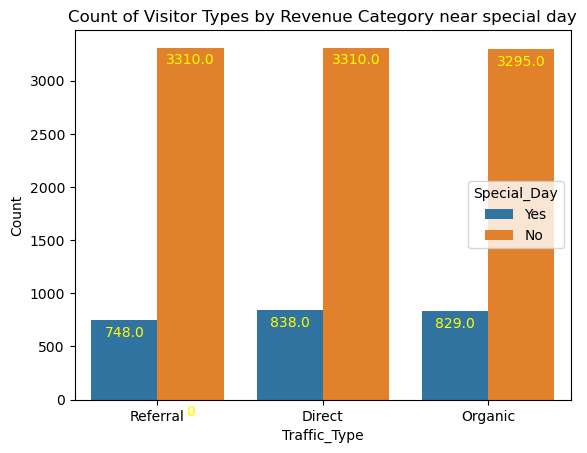

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


retail = pd.read_csv('synthetic_datasetA.csv')
ax = sns.countplot(x='Traffic_Type', hue='Special_Day', data=retail)

for p in ax.patches:
     ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()+100), ha='center', va='top', color='yellow', size=10)

plt.title('Count of Visitor Types by Revenue Category near special day')
plt.xlabel('Traffic_Type')
plt.ylabel('Count')

plt.show()






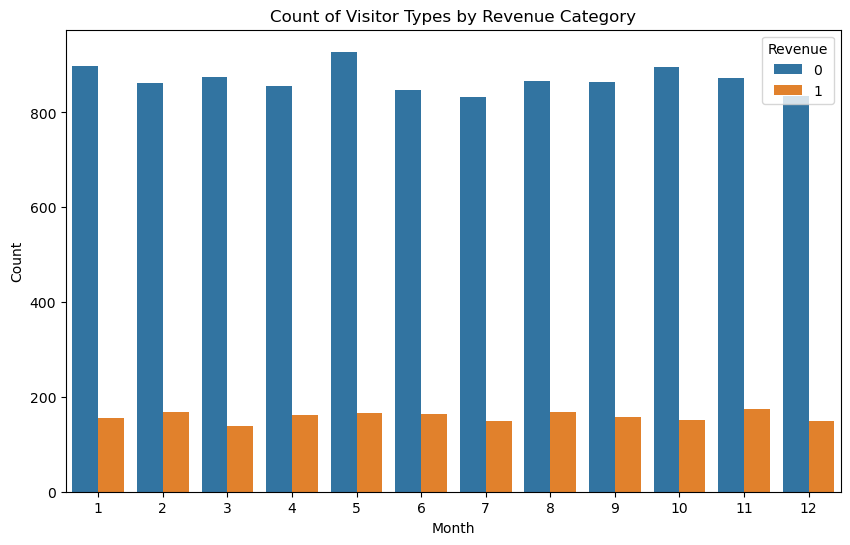

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


retail = pd.read_csv('synthetic_datasetA.csv')




plt.figure(figsize=(10, 6))
sns.countplot(x='Month', hue='Revenue', data=retail)


plt.title('Count of Visitor Types by Revenue Category')
plt.xlabel('Month')
plt.ylabel('Count')


plt.show()

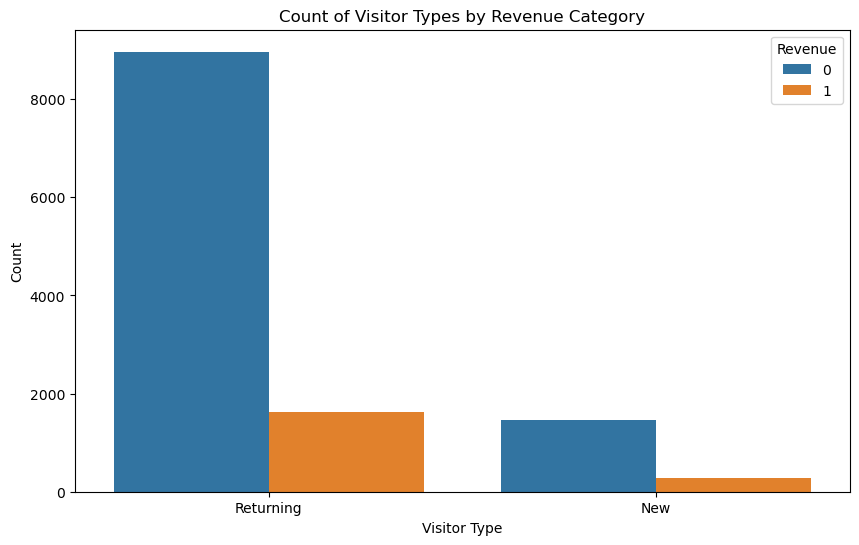

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


retail = pd.read_csv('synthetic_datasetA.csv')




plt.figure(figsize=(10, 6))
sns.countplot(x='Visitor_Type', hue='Revenue', data=retail)


plt.title('Count of Visitor Types by Revenue Category')
plt.xlabel('Visitor Type')
plt.ylabel('Count')


plt.show()


In [100]:
retail['Session_ID'] = retail['Session_ID'].astype(str)

In [101]:
retail['Page_Values']
rfm_p = retail.groupby('Session_ID') ['Page_Values'].sum()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,Session_ID,Page_Values
0,1,11.344093
1,10,3.790016
2,100,6.672474
3,1000,9.398404
4,10000,15.366995


In [102]:
retail['Bounce_Rate']
rfm_b = retail.groupby('Session_ID') ['Bounce_Rate'].sum()
rfm_b = rfm_b.reset_index()
rfm_b.head()

,Session_ID,Bounce_Rate
0,1,0.102045
1,10,0.092660
2,100,0.810888
3,1000,0.143419
4,10000,0.039968


In [103]:
retail['Exit_Rate']
rfm_e = retail.groupby('Session_ID') ['Exit_Rate'].sum()
rfm_e = rfm_e.reset_index()
rfm_e.head()

,Session_ID,Exit_Rate
0,1,0.208638
1,10,0.262278
2,100,0.190463
3,1000,0.060115
4,10000,0.320129


In [104]:
retail['Total_Page_Views']
rfm_t = retail.groupby('Session_ID') ['Total_Page_Views'].sum()
rfm_t = rfm_t.reset_index()
rfm_t.head()

,Session_ID,Total_Page_Views
0,1,8
1,10,10
2,100,10
3,1000,9
4,10000,14


In [105]:
retail['Total_Page_Duration']
rfm_tp = retail.groupby('Session_ID') ['Total_Page_Duration'].sum()
rfm_tp= rfm_tp.reset_index()
rfm_tp.head()

,Session_ID,Total_Page_Duration
0,1,6.560012
1,10,4.907233
2,100,5.828586
3,1000,6.448837
4,10000,4.335909


In [106]:
rfm_p['Session_ID'] = rfm_p['Session_ID'].astype(str)
rfm_b['Session_ID'] = rfm_b['Session_ID'].astype(str)
rfm_e['Session_ID'] = rfm_e['Session_ID'].astype(str)
rfm_t['Session_ID'] = rfm_t['Session_ID'].astype(str)
rfm_tp['Session_ID'] = rfm_tp['Session_ID'].astype(str)
rfm = pd.merge(rfm_p, rfm_b, on='Session_ID', how='inner')
rfm = pd.merge(rfm, rfm_e, on='Session_ID', how='inner')
rfm = pd.merge(rfm, rfm_t, on='Session_ID', how='inner')
rfm = pd.merge(rfm, rfm_tp, on='Session_ID', how='inner')


rfm.head()


,Session_ID,Page_Values,Bounce_Rate,Exit_Rate,Total_Page_Views,Total_Page_Duration
0,1,11.344093,0.102045,0.208638,8,6.560012
1,10,3.790016,0.092660,0.262278,10,4.907233
2,100,6.672474,0.810888,0.190463,10,5.828586
3,1000,9.398404,0.143419,0.060115,9,6.448837
4,10000,15.366995,0.039968,0.320129,14,4.335909


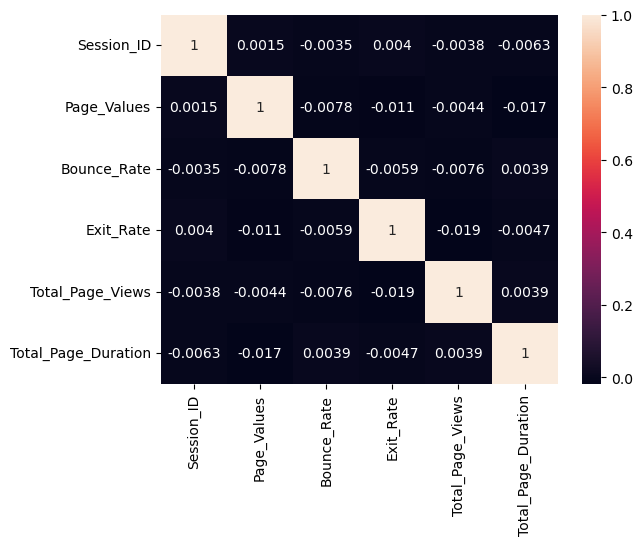

In [107]:
sns.heatmap(rfm.corr(), annot=True);

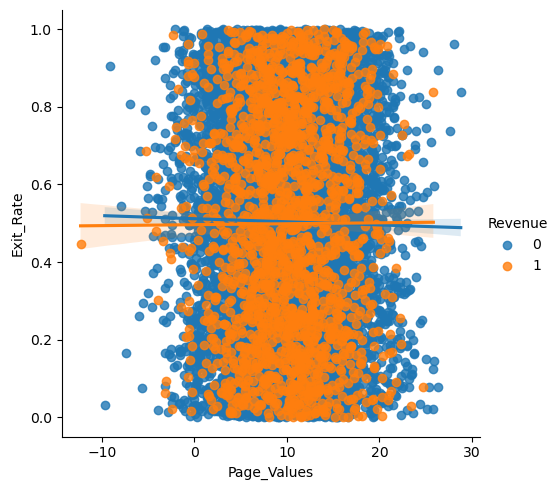

In [108]:
sns.lmplot(x="Page_Values",y="Exit_Rate",hue="Revenue",data=retail)

In [109]:
retail.head()

,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,Region,Weekend,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,North America,Yes,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,Asia,No,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,Europe,Yes,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,North America,Yes,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,Europe,No,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [177]:
def calculate_length(row):
    
    month = int(row['Month'])  
    if row['Visitor_Type'] == 'Returning':
        return (month - 1)
    else:
        return 1


retail['Length'] = retail.apply(calculate_length, axis=1)


print(retail[['Length']].head())




   Length
0       3
1       5
2      10
3       4
4       9


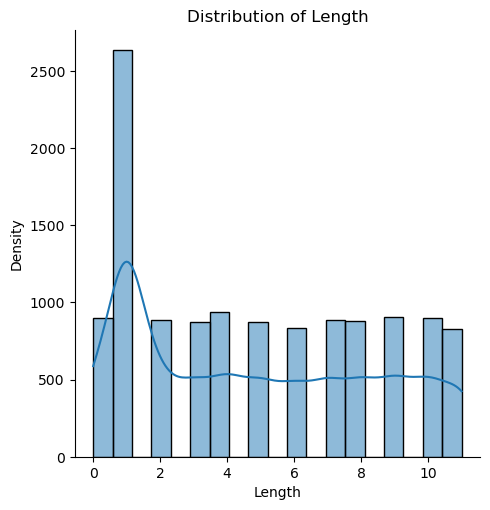

In [111]:
sns.displot(retail['Length'], kde=True)
plt.title("Distribution of Length")
plt.xlabel("Length")
plt.ylabel("Density")
plt.show()

In [112]:
retail['Length']
retail.head()

,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,Weekend,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Length
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,Yes,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,3
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,No,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,5
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,Yes,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,10
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,Yes,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,4
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,No,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,9


In [113]:
import pandas as pd


retail['Month'] = pd.to_numeric(retail['Month'], errors='coerce')  


month_max = retail['Month'].max()  

def calculate_recency(row):
   
    return month_max - row['Month'] + 1

retail['Recency'] = retail.apply(calculate_recency, axis=1)


print(retail['Recency'].head())


0    9
1    7
2    2
3    8
4    3
Name: Recency, dtype: int64


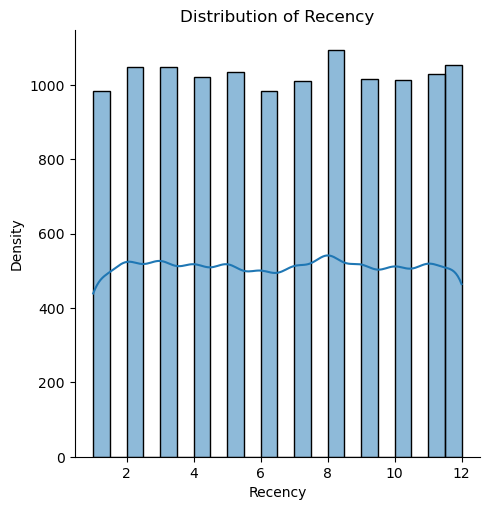

In [114]:
sns.displot(retail['Recency'], kde=True)
plt.title("Distribution of Recency")
plt.xlabel("Recency")
plt.ylabel("Density")
plt.show()

In [178]:
import pandas as pd


print(retail.columns)


retail.columns = retail.columns.str.strip()


print(retail.columns)

retail['Frequency'] = retail['Total_Page_Views'] 

print(retail[['Total_Page_Views', 'Frequency']].head())


Index(['Session_ID', 'Revenue', 'Total_Page_Views', 'Total_Page_Duration',
       'Bounce_Rate', 'Exit_Rate', 'Page_Values', 'Total_Visits', 'Month',
       'Visitor_Type', 'Traffic_Type', 'Special_Day', 'Operating_System',
       'Browser', 'Region', 'Weekend', 'InvoiceNo', 'StockCode', 'Description',
       'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'Length'],
      dtype='object')
Index(['Session_ID', 'Revenue', 'Total_Page_Views', 'Total_Page_Duration',
       'Bounce_Rate', 'Exit_Rate', 'Page_Values', 'Total_Visits', 'Month',
       'Visitor_Type', 'Traffic_Type', 'Special_Day', 'Operating_System',
       'Browser', 'Region', 'Weekend', 'InvoiceNo', 'StockCode', 'Description',
       'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'Length'],
      dtype='object')
   Total_Page_Views  Frequency
0                 8          8
1                 7          7
2                13         13
3                12         12
4            

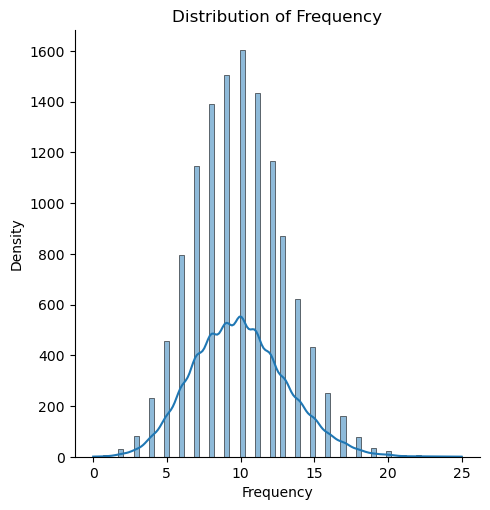

In [116]:
sns.displot(retail['Frequency'], kde=True)
plt.title("Distribution of Frequency")
plt.xlabel("Frequency")
plt.ylabel("Density")
plt.show()

In [117]:
retail.head()

,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Length,Recency,Frequency
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,3,9,8
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,5,7,7
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,10,2,13
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,4,8,12
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,9,3,8


   Staying Rate for Revenue
0                  8.977283
1                  2.307219
2                  6.261573
3                  2.747704
4                  4.418970


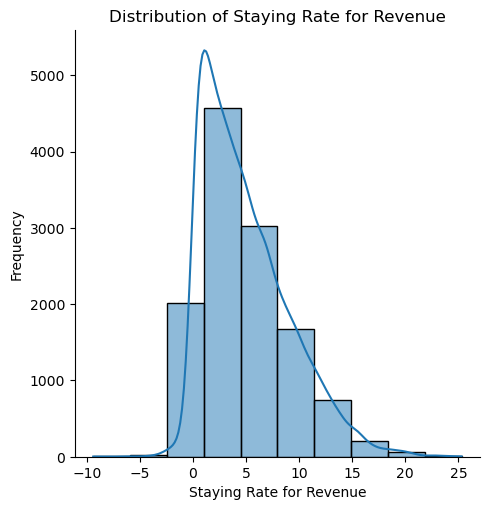

In [118]:

import pandas as pd
import numpy as np



retail['StayingRate'] = 1 - retail['Exit_Rate']


retail['Staying Rate for Revenue'] = retail['Page_Values'] * retail['StayingRate']

print(retail[['Staying Rate for Revenue']].head())


import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(retail['Staying Rate for Revenue'], kde=True, bins=10)
plt.title('Distribution of Staying Rate for Revenue')
plt.xlabel('Staying Rate for Revenue')
plt.ylabel('Frequency')
plt.show()



In [119]:
retail['Session_ID'] = retail['Session_ID'].astype(str)


In [120]:
retail['Length']
rfm_Le = retail.groupby('Session_ID') ['Length'].sum()
rfm_Le = rfm_Le.reset_index()
rfm_Le.head()

,Session_ID,Length
0,1,3
1,10,3
2,100,1
3,1000,8
4,10000,4


In [121]:
retail['Recency']
rfm_De = retail.groupby('Session_ID') ['Recency'].sum()
rfm_De = rfm_De.reset_index()
rfm_De.head()

,Session_ID,Recency
0,1,9
1,10,9
2,100,5
3,1000,4
4,10000,8


In [122]:
retail['Frequency']
rfm_Fr = retail.groupby('Session_ID') ['Frequency'].sum()
rfm_Fr = rfm_Fr.reset_index()
rfm_Fr.head()

,Session_ID,Frequency
0,1,8
1,10,10
2,100,10
3,1000,9
4,10000,14


In [123]:
retail['StayingRate']
rfm_St = retail.groupby('Session_ID') ['StayingRate'].sum()
rfm_St = rfm_St.reset_index()
rfm_St.head()

,Session_ID,StayingRate
0,1,0.791362
1,10,0.737722
2,100,0.809537
3,1000,0.939885
4,10000,0.679871


In [124]:
retail['Revenue']
rfm_Rv = retail.groupby('Session_ID') ['Revenue'].sum()
rfm_Rv= rfm_Rv.reset_index()
rfm_Rv.head()

,Session_ID,Revenue
0,1,0
1,10,0
2,100,0
3,1000,0
4,10000,0


In [125]:
rfm_Le['Session_ID'] = rfm_Le['Session_ID'].astype(str)
rfm_Fr['Session_ID'] = rfm_Fr['Session_ID'].astype(str)
rfm_St['Session_ID'] = rfm_St['Session_ID'].astype(str)
rfm_De['Session_ID'] = rfm_De['Session_ID'].astype(str)
rfm_Rv['Session_ID'] = rfm_Rv['Session_ID'].astype(str)


rfm = pd.merge(rfm_Le, rfm_Fr, on='Session_ID', how='inner')
rfm = pd.merge(rfm, rfm_St, on='Session_ID', how='inner')
rfm= pd.merge(rfm, rfm_De, on='Session_ID', how='inner')
rfm= pd.merge(rfm, rfm_Rv, on='Session_ID', how='inner')


rfm.head()

,Session_ID,Length,Frequency,StayingRate,Recency,Revenue
0,1,3,8,0.791362,9,0
1,10,3,10,0.737722,9,0
2,100,1,10,0.809537,5,0
3,1000,8,9,0.939885,4,0
4,10000,4,14,0.679871,8,0


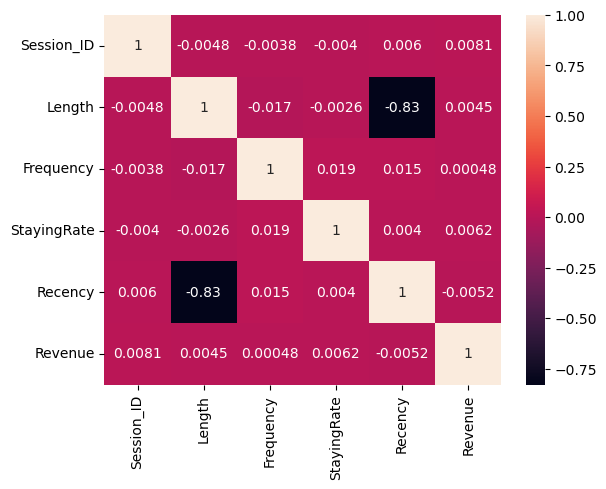

In [126]:
sns.heatmap(rfm.corr(), annot=True);

In [127]:
rfm.head()

,Session_ID,Length,Frequency,StayingRate,Recency,Revenue
0,1,3,8,0.791362,9,0
1,10,3,10,0.737722,9,0
2,100,1,10,0.809537,5,0
3,1000,8,9,0.939885,4,0
4,10000,4,14,0.679871,8,0


In [128]:
Q1 = rfm.StayingRate.quantile (0.05)
Q3 = rfm.StayingRate.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm. StayingRate >= Q1 - 1.5*IQR) & (rfm. StayingRate <= Q3 + 1.5*IQR)]

In [129]:
Q1 = rfm. Frequency.quantile (0.05)
Q3 = rfm. Frequency.quantile (0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm. Frequency >= Q1 - 1.5*IQR) & (rfm. Frequency <= Q3 +1.5*IQR)]

In [130]:
Q1 = rfm. Length.quantile (0.05)
Q3 = rfm. Length.quantile (0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm. Length >= Q1 - 1.5*IQR) & (rfm. Length<= Q3 +1.5*IQR)]

In [131]:
Q1 = rfm. Recency.quantile(0.05)
Q3 = rfm. Recency.quantile (0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm. Recency >= Q1 - 1.5*IQR) & (rfm. Recency <= Q3 + 1.5*IQR)]

In [132]:
rfm_df = rfm[['StayingRate', 'Frequency','Length', 'Recency']]
scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

(12330, 4)

In [133]:
rfm_df_scaled = pd. DataFrame (rfm_df_scaled)
rfm_df_scaled.columns = ['StayingRate', 'Frequency','Length', 'Recency']

In [134]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit (rfm_df_scaled)

KMeans(max_iter=50, n_clusters=4)

In [135]:
kmeans.labels_

array([1, 1, 1, ..., 1, 0, 3])

In [136]:
set(kmeans.labels_)

{0, 1, 2, 3}

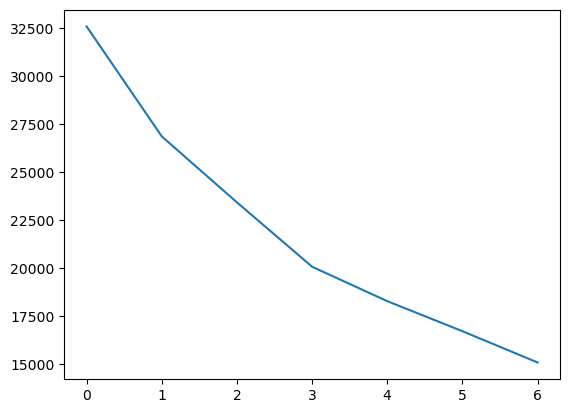

In [137]:
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8] 
for num_clusters in range_n_clusters:
    kmeans = KMeans (n_clusters=num_clusters, max_iter=50)
    kmeans.fit (rfm_df_scaled)
    ssd.append (kmeans. inertia_)
plt.plot(ssd)

In [138]:
kmeans = KMeans(n_clusters=3, max_iter=300)
kmeans.fit(rfm_df_scaled)

KMeans(n_clusters=3)

In [139]:
kmeans.labels_

array([2, 2, 2, ..., 2, 1, 0])

In [140]:
kmeans.predict(rfm_df_scaled)

array([2, 2, 2, ..., 2, 1, 0])

In [141]:
rfm[ 'Cluster_Id'] = kmeans.predict(rfm_df_scaled)
rfm.head()

,Session_ID,Length,Frequency,StayingRate,Recency,Revenue,Cluster_Id
0,1,3,8,0.791362,9,0,2
1,10,3,10,0.737722,9,0,2
2,100,1,10,0.809537,5,0,2
3,1000,8,9,0.939885,4,0,1
4,10000,4,14,0.679871,8,0,2


In [142]:
filename= 'kmeans_modelG.pkl'
with open('kmeans_saved_modelY', 'wb') as file:
    pickle.dump (kmeans, file)
file.close()
pickle.dump(kmeans, open('kmeans_modelG.pkl', 'wb'))

In [143]:
with open('kmeans_saved_modelY', 'rb')as file:
    mp= pickle.load(file)

In [144]:
import joblib

# Saving a model (example: clf)
joblib.dump(kmeans, 'kmeans_joblibG')

# Loading the model
loaded_model = joblib.load('kmeans_joblibG')



In [145]:
mj=joblib.load('kmeans_joblibG')

In [146]:
kmeans.labels_

array([2, 2, 2, ..., 2, 1, 0])

In [147]:
rfm['Cluster_Id']=kmeans.predict(rfm_df_scaled)
rfm.head()

,Session_ID,Length,Frequency,StayingRate,Recency,Revenue,Cluster_Id
0,1,3,8,0.791362,9,0,2
1,10,3,10,0.737722,9,0,2
2,100,1,10,0.809537,5,0,2
3,1000,8,9,0.939885,4,0,1
4,10000,4,14,0.679871,8,0,2


<Axes: xlabel='Cluster_Id', ylabel='StayingRate'>

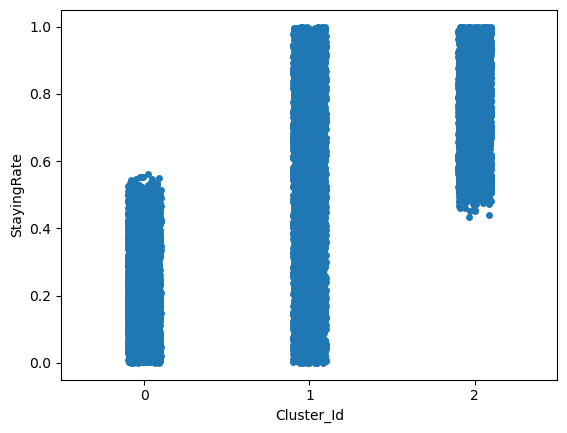

In [148]:
sns.stripplot(x='Cluster_Id',y='StayingRate',data=rfm)

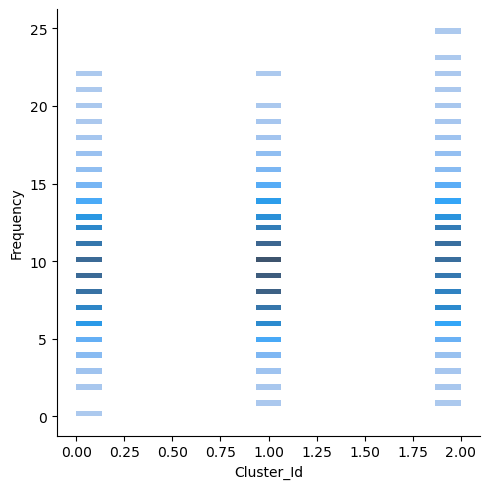

In [149]:
sns.displot(x='Cluster_Id',y='Frequency',data=rfm)

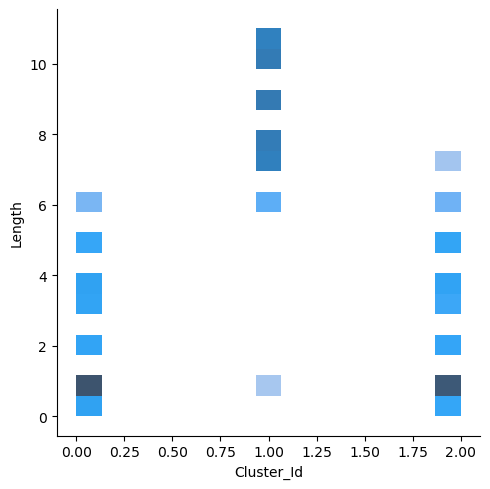

In [150]:
sns.displot(x='Cluster_Id',y='Length',data=rfm)

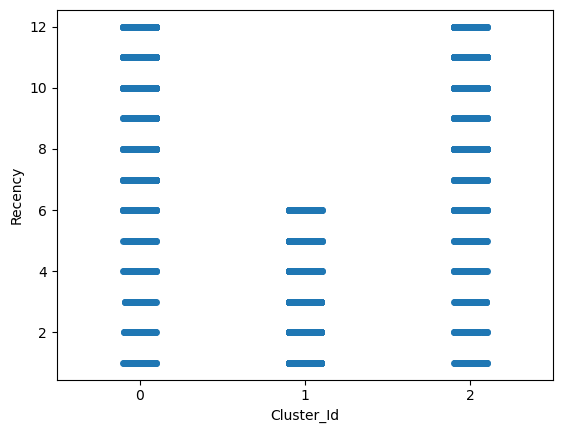

In [151]:
sns.stripplot(x='Cluster_Id',y='Recency',data=rfm)
plt.savefig("Cluster_IdRecency.png")

In [152]:
retail.head()


,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Length,Recency,Frequency,StayingRate,Staying Rate for Revenue
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,3,9,8,0.791362,8.977283
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,5,7,7,0.230218,2.307219
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,10,2,13,0.375076,6.261573
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,4,8,12,0.264876,2.747704
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,9,3,8,0.630178,4.418970


In [153]:
retail.head()

,Session_ID,Revenue,Total_Page_Views,Total_Page_Duration,Bounce_Rate,Exit_Rate,Page_Values,Total_Visits,Month,Visitor_Type,...,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Length,Recency,Frequency,StayingRate,Staying Rate for Revenue
0,1,0,8,6.560012,0.102045,0.208638,11.344093,3,4,Returning,...,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,3,9,8,0.791362,8.977283
1,2,1,7,4.930635,0.002988,0.769782,10.021889,6,6,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,5,7,7,0.230218,2.307219
2,3,0,13,8.462505,0.191901,0.624924,16.694149,3,11,Returning,...,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,10,2,13,0.375076,6.261573
3,4,0,12,5.825029,0.188532,0.735124,10.373548,9,5,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,4,8,12,0.264876,2.747704
4,5,0,8,5.712455,0.182517,0.369822,7.012260,13,10,Returning,...,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,9,3,8,0.630178,4.418970


In [154]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [155]:
retail = pd.read_csv('synthetic_datasetA.csv' )

In [156]:
retail_encoded = pd.get_dummies(retail, drop_first=True) 
X_scaled = scaler.fit_transform(retail_encoded)


In [157]:
X_scaled_clean = X_scaled[~np.isnan(X_scaled).any(axis=1)]  


In [158]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  
X_scaled_imputed = imputer.fit_transform(X_scaled)


In [179]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_imputed)


print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


Explained Variance Ratio: [0.00086445 0.00072482]


In [160]:

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_pca)

labels = kmeans.labels_


centroids = kmeans.cluster_centers_



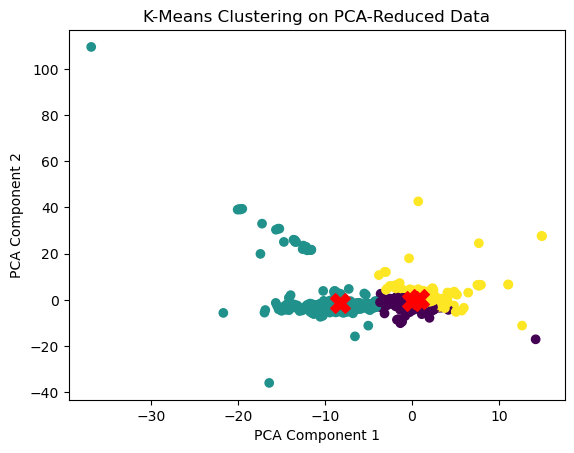

In [161]:
# Visualize the PCA + K-Means result
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red')  
plt.title("K-Means Clustering on PCA-Reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [162]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_pca, labels)
print(f"Silhouette Score: {sil_score}")


Silhouette Score: 0.3074652981285149


In [163]:
rfm.head()

,Session_ID,Length,Frequency,StayingRate,Recency,Revenue,Cluster_Id
0,1,3,8,0.791362,9,0,2
1,10,3,10,0.737722,9,0,2
2,100,1,10,0.809537,5,0,2
3,1000,8,9,0.939885,4,0,1
4,10000,4,14,0.679871,8,0,2


In [184]:

features = ['Length', 'Recency', 'StayingRate','Frequency','Recency']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm[features])


print(scaled_data)


[[-0.5162295   0.71811489  1.02136637 -0.6289401   0.71811489]
 [-0.5162295   0.71811489  0.83528992  0.01174326  0.71811489]
 [-1.07894087 -0.44075647  1.08441483  0.01174326 -0.44075647]
 ...
 [-0.23487381  0.42839705  1.59273238 -0.6289401   0.42839705]
 [ 1.73461599 -1.59962782  1.26519785  0.97276831 -1.59962782]
 [-0.23487381  0.42839705 -1.61545278 -1.26962346  0.42839705]]


In [181]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)


rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]


print(rfm[['Length', 'PCA1', 'PCA2']])


       Length      PCA1      PCA2
0           3  1.125812  0.268124
1           3  1.134987  0.586514
2           1  0.078648  0.780134
3           8 -1.351805  0.892813
4           4  0.657077  1.351797
...       ...       ...       ...
12325       4  0.604488 -2.294522
12326       8 -1.348080  0.883096
12327       4  0.631003  0.680835
12328      11 -2.823737  1.621125
12329       4  0.609512 -2.049858

[12330 rows x 3 columns]


In [183]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(pca_result)

print(rfm[['Length', 'Cluster']])


       Length  Cluster
0           3        2
1           3        2
2           1        0
3           8        1
4           4        0
...       ...      ...
12325       4        2
12326       8        1
12327       4        0
12328      11        1
12329       4        2

[12330 rows x 2 columns]


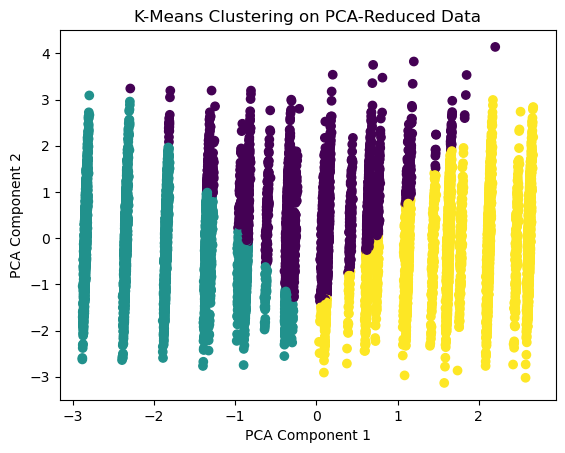

In [167]:
import matplotlib.pyplot as plt


plt.scatter(rfm['PCA1'], rfm['PCA2'], c=rfm['Cluster'], cmap='viridis')
plt.title("K-Means Clustering on PCA-Reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [168]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(pca_result)

# Check the clustering results
print(rfm[['Recency', 'Cluster']])

       Recency  Cluster
0            9        2
1            9        2
2            5        0
3            4        1
4            8        0
...        ...      ...
12325        8        2
12326        4        1
12327        8        0
12328        1        1
12329        8        2

[12330 rows x 2 columns]


In [185]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]



print(rfm[['Recency', 'PCA1', 'PCA2']])


       Recency      PCA1      PCA2
0            9  1.125812  0.268124
1            9  1.134987  0.586514
2            5  0.078648  0.780134
3            4 -1.351805  0.892813
4            8  0.657077  1.351797
...        ...       ...       ...
12325        8  0.604488 -2.294522
12326        4 -1.348080  0.883096
12327        8  0.631003  0.680835
12328        1 -2.823737  1.621125
12329        8  0.609512 -2.049858

[12330 rows x 3 columns]


<BarContainer object of 12330 artists>

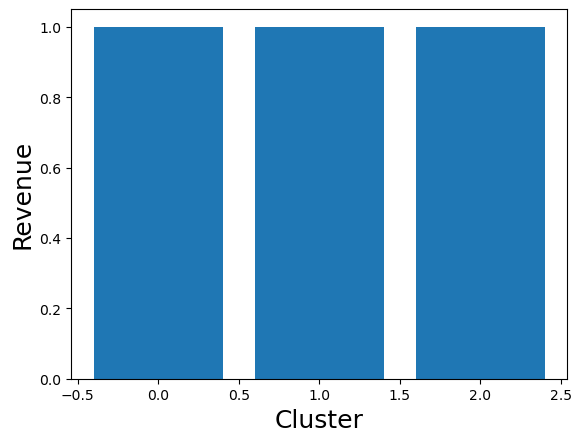

In [170]:
x=rfm['Cluster']
y=rfm['Revenue']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('Revenue',fontsize=18)
plt.bar(x,y)

In [171]:
print(rfm[['Length', 'Cluster']])

       Length  Cluster
0           3        2
1           3        2
2           1        0
3           8        1
4           4        0
...       ...      ...
12325       4        2
12326       8        1
12327       4        0
12328      11        1
12329       4        2

[12330 rows x 2 columns]


<BarContainer object of 12330 artists>

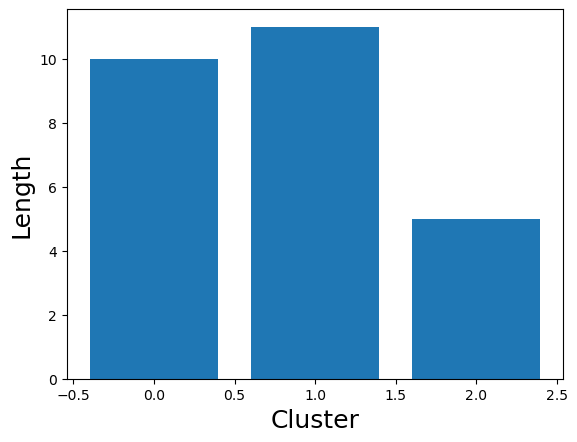

In [172]:
x=rfm['Cluster']
y=rfm['Length']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('Length',fontsize=18)
plt.bar(x,y)


<BarContainer object of 12330 artists>

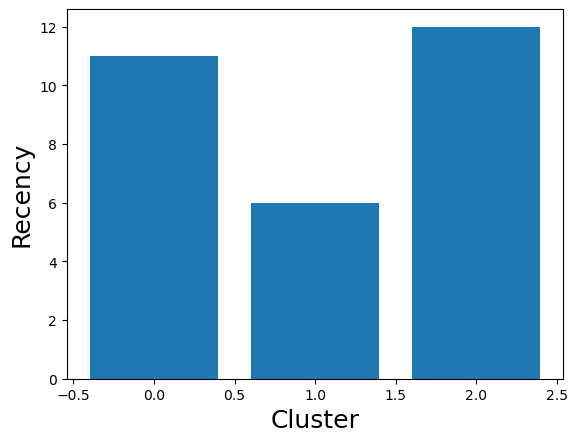

In [173]:
x=rfm['Cluster']
y=rfm['Recency']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('Recency',fontsize=18)
plt.bar(x,y)


<BarContainer object of 12330 artists>

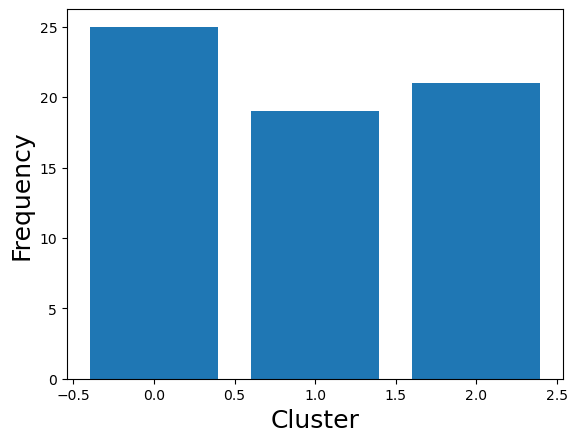

In [174]:
x=rfm['Cluster']
y=rfm['Frequency']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('Frequency',fontsize=18)
plt.bar(x,y)


<BarContainer object of 12330 artists>

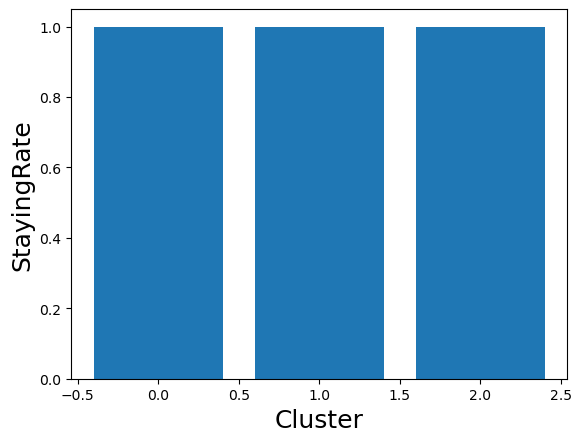

In [175]:
x=rfm['Cluster']
y=rfm['StayingRate']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('StayingRate',fontsize=18)
plt.bar(x,y)


<BarContainer object of 12330 artists>

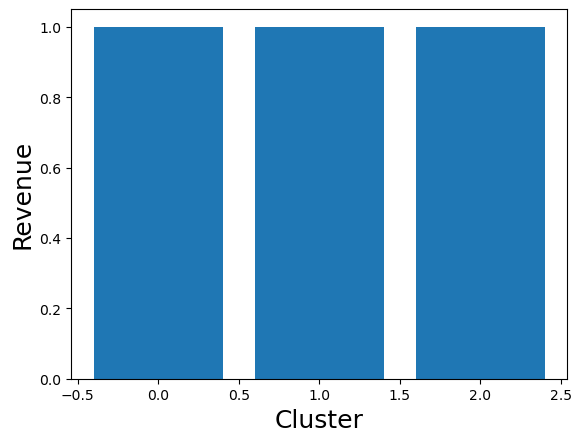

In [176]:
x=rfm['Cluster']
y=rfm['Revenue']
plt.xlabel('Cluster',fontsize=18)
plt.ylabel('Revenue',fontsize=18)
plt.bar(x,y)